[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tanisha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tanisha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


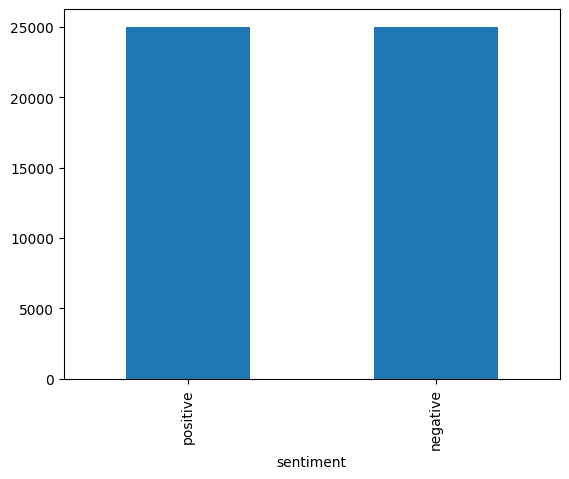

,text,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

df = pd.read_csv(r"IMDB Dataset.csv", encoding='latin-1')

df = df.rename(columns={'review': 'text', 'sentiment': 'sentiment'})

df.dropna(inplace=True)

print(df.shape)
print(df['sentiment'].value_counts())

df['sentiment'].value_counts().plot(kind='bar')
plt.show()

df.head()

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

df = df.head(5000)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode hooked...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [8]:
y = df['sentiment']

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text']).toarray()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.861,0.861461,0.861,0.861085
Naive Bayes,0.826,0.825921,0.826,0.825931
Decision Tree,0.694,0.693865,0.694,0.693921


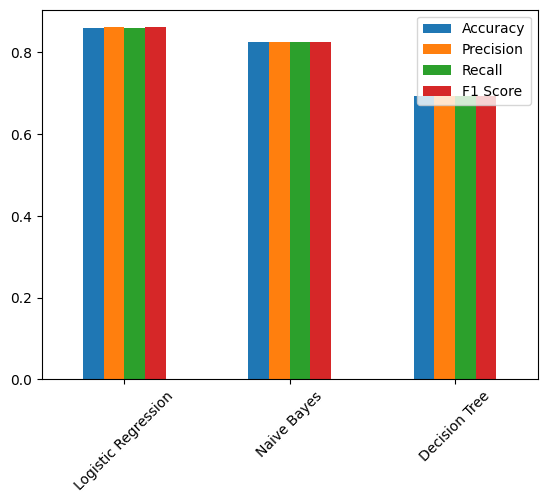

Best Model: Logistic Regression


In [12]:
results_df.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

print("Best Model:", results_df['Accuracy'].idxmax())

Conclusion:

Text preprocessing was performed using lowercasing, removing punctuation, removing stopwords, and lemmatization.

TF-IDF was used for feature extraction and performed effectively.

Logistic Regression achieved the best performance among all models.

Naive Bayes also performed well for text classification.

Decision Tree showed lower performance due to overfitting.

Thus, the best pipeline is:
Preprocessing → TF-IDF → Logistic Regression